In [10]:
# importing important libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [11]:
# reading the csv file
df = pd.read_csv('country_wise_latest.csv',encoding='latin-1')

In [12]:
# loading the top 5 rows of the data set
df.head()

,Country/Region,Confirmed,Deaths,Recovered,Active,New cases,New deaths,New recovered,Deaths / 100 Cases,Recovered / 100 Cases,Deaths / 100 Recovered,Confirmed last week,1 week change,1 week % increase,WHO Region
0,Afghanistan,36263,1269,25198,9796,106,10,18,3.50,69.49,5.04,35526,737,2.07,Eastern Mediterranean
1,Albania,4880,144,2745,1991,117,6,63,2.95,56.25,5.25,4171,709,17.00,Europe
2,Algeria,27973,1163,18837,7973,616,8,749,4.16,67.34,6.17,23691,4282,18.07,Africa
3,Andorra,907,52,803,52,10,0,0,5.73,88.53,6.48,884,23,2.60,Europe
4,Angola,950,41,242,667,18,1,0,4.32,25.47,16.94,749,201,26.84,Africa


In [15]:
print("Shape of dataset :",df.shape)

Shape of dataset : (187, 15)


In [16]:
print("\nColumns:\n",df.columns.tolist())


Columns:
 ['Country/Region', 'Confirmed', 'Deaths', 'Recovered', 'Active', 'New cases', 'New deaths', 'New recovered', 'Deaths / 100 Cases', 'Recovered / 100 Cases', 'Deaths / 100 Recovered', 'Confirmed last week', '1 week change', '1 week % increase', 'WHO Region']


In [17]:
print("Missing Values: ",df.isnull().sum())

Missing Values:  Country/Region            0
Confirmed                 0
Deaths                    0
Recovered                 0
Active                    0
New cases                 0
New deaths                0
New recovered             0
Deaths / 100 Cases        0
Recovered / 100 Cases     0
Deaths / 100 Recovered    0
Confirmed last week       0
1 week change             0
1 week % increase         0
WHO Region                0
dtype: int64


In [18]:
df.describe()

,Confirmed,Deaths,Recovered,Active,New cases,New deaths,New recovered,Deaths / 100 Cases,Recovered / 100 Cases,Deaths / 100 Recovered,Confirmed last week,1 week change,1 week % increase
count,1.870000e+02,187.000000,1.870000e+02,1.870000e+02,187.000000,187.000000,187.000000,187.000000,187.000000,187.00,1.870000e+02,187.000000,187.000000
mean,8.813094e+04,3497.518717,5.063148e+04,3.400194e+04,1222.957219,28.957219,933.812834,3.019519,64.820535,inf,7.868248e+04,9448.459893,13.606203
std,3.833187e+05,14100.002482,1.901882e+05,2.133262e+05,5710.374790,120.037173,4197.719635,3.454302,26.287694,NaN,3.382737e+05,47491.127684,24.509838
min,1.000000e+01,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.00,1.000000e+01,-47.000000,-3.840000
25%,1.114000e+03,18.500000,6.265000e+02,1.415000e+02,4.000000,0.000000,0.000000,0.945000,48.770000,1.45,1.051500e+03,49.000000,2.775000
50%,5.059000e+03,108.000000,2.815000e+03,1.600000e+03,49.000000,1.000000,22.000000,2.150000,71.320000,3.62,5.020000e+03,432.000000,6.890000
75%,4.046050e+04,734.000000,2.260600e+04,9.149000e+03,419.500000,6.000000,221.000000,3.875000,86.885000,6.44,3.708050e+04,3172.000000,16.855000
max,4.290259e+06,148011.000000,1.846641e+06,2.816444e+06,56336.000000,1076.000000,33728.000000,28.560000,100.000000,inf,3.834677e+06,455582.000000,226.320000


In [19]:
print("Column Names & Data Types:\n",df.dtypes)

Column Names & Data Types:
 Country/Region             object
Confirmed                   int64
Deaths                      int64
Recovered                   int64
Active                      int64
New cases                   int64
New deaths                  int64
New recovered               int64
Deaths / 100 Cases        float64
Recovered / 100 Cases     float64
Deaths / 100 Recovered    float64
Confirmed last week         int64
1 week change               int64
1 week % increase         float64
WHO Region                 object
dtype: object


In [21]:
# Top 10 countries with most confirmed cases
top_confirmed = df[['Country/Region', 'Confirmed']].sort_values(
                'Confirmed', ascending=False).head(10)
print("Top 10 Countries by Confirmed Cases:\n",top_confirmed)

Top 10 Countries by Confirmed Cases:
      Country/Region  Confirmed
173              US    4290259
23           Brazil    2442375
79            India    1480073
138          Russia     816680
154    South Africa     452529
111          Mexico     395489
132            Peru     389717
35            Chile     347923
177  United Kingdom     301708
81             Iran     293606


In [23]:
# Top 10 countries with most deaths
top_deaths = df[['Country/Region', 'Deaths']].sort_values(
             'Deaths', ascending=False).head(10)
print("Top 10 Countries by Deaths:\n",top_deaths)

Top 10 Countries by Deaths:
      Country/Region  Deaths
173              US  148011
23           Brazil   87618
177  United Kingdom   45844
111          Mexico   44022
85            Italy   35112
79            India   33408
61           France   30212
157           Spain   28432
132            Peru   18418
81             Iran   15912


In [24]:
# Top 10 countries with most recovered
top_recovered = df[['Country/Region', 'Recovered']].sort_values(
                'Recovered', ascending=False).head(10)
print("Top 10 Countries by Recovered:\n",top_recovered)

Top 10 Countries by Recovered:
     Country/Region  Recovered
23          Brazil    1846641
173             US    1325804
79           India     951166
138         Russia     602249
35           Chile     319954
111         Mexico     303810
154   South Africa     274925
132           Peru     272547
81            Iran     255144
128       Pakistan     241026


In [25]:
# Adding new columns - Death Rate and Recovery Rate
df['Death Rate'] = (df['Deaths'] / df['Confirmed']) * 100
df['Recovery Rate'] = (df['Recovered'] / df['Confirmed']) * 100

print("Death Rate & Recovery Rate columns added!")
df[['Country/Region', 'Confirmed', 'Deaths', 'Death Rate', 'Recovery Rate']].head(10)

Death Rate & Recovery Rate columns added!


,Country/Region,Confirmed,Deaths,Death Rate,Recovery Rate
0,Afghanistan,36263,1269,3.499435,69.486805
1,Albania,4880,144,2.950820,56.250000
2,Algeria,27973,1163,4.157581,67.339935
3,Andorra,907,52,5.733186,88.533627
4,Angola,950,41,4.315789,25.473684
5,Antigua and Barbuda,86,3,3.488372,75.581395
6,Argentina,167416,3059,1.827185,43.350098
7,Armenia,37390,711,1.901578,71.315860
8,Australia,15303,167,1.091289,60.844279
9,Austria,20558,713,3.468236,88.753770


In [26]:
# Global summary
print("=" * 50)
print("        GLOBAL COVID-19 SUMMARY")
print("=" * 50)
print(f"Total Confirmed Cases : {df['Confirmed'].sum():,}")
print(f"Total Deaths          : {df['Deaths'].sum():,}")
print(f"Total Recovered       : {df['Recovered'].sum():,}")
print(f"Total Active Cases    : {df['Active'].sum():,}")
print(f"Average Death Rate    : {df['Death Rate'].mean():.2f}%")
print(f"Average Recovery Rate : {df['Recovery Rate'].mean():.2f}%")
print("=" * 50)

        GLOBAL COVID-19 SUMMARY
Total Confirmed Cases : 16,480,485
Total Deaths          : 654,036
Total Recovered       : 9,468,087
Total Active Cases    : 6,358,362
Average Death Rate    : 3.02%
Average Recovery Rate : 64.82%


In [27]:
# WHO Region wise summary
region_summary = df.groupby('WHO Region')[['Confirmed', 'Deaths', 'Recovered']].sum()
region_summary = region_summary.sort_values('Confirmed', ascending=False)
print("WHO Region wise Summary:\n")
print(region_summary)

WHO Region wise Summary:

                       Confirmed  Deaths  Recovered
WHO Region                                         
Americas                 8839286  342732    4468616
Europe                   3299523  211144    1993723
South-East Asia          1835297   41349    1156933
Eastern Mediterranean    1490744   38339    1201400
Africa                    723207   12223     440645
Western Pacific           292428    8249     206770


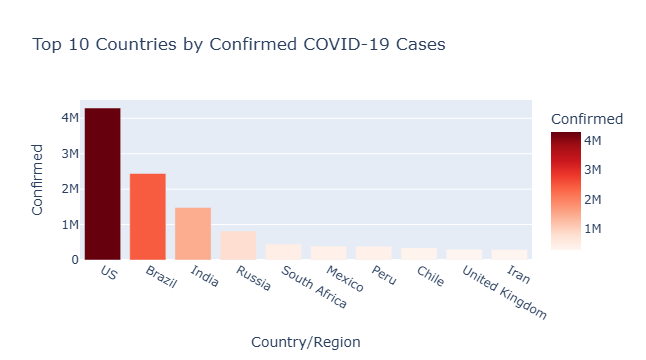

In [29]:
# Top 10 countries by confirmed cases
top10 = df.sort_values('Confirmed', ascending=False).head(10)

fig = px.bar(top10, 
             x='Country/Region', 
             y='Confirmed',
             color='Confirmed',
             title='Top 10 Countries by Confirmed COVID-19 Cases',
             color_continuous_scale='Reds')
fig.show()

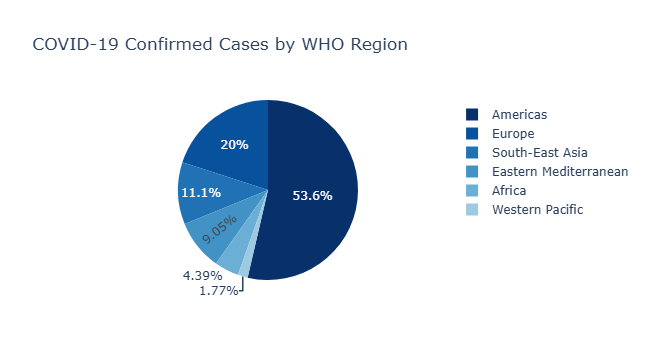

In [32]:
# WHO Region wise pie chart
region_data = df.groupby('WHO Region')['Confirmed'].sum().reset_index()

fig = px.pie(region_data, 
             values='Confirmed', 
             names='WHO Region',
             title='COVID-19 Confirmed Cases by WHO Region',
             color_discrete_sequence=px.colors.sequential.Blues_r)
fig.show()

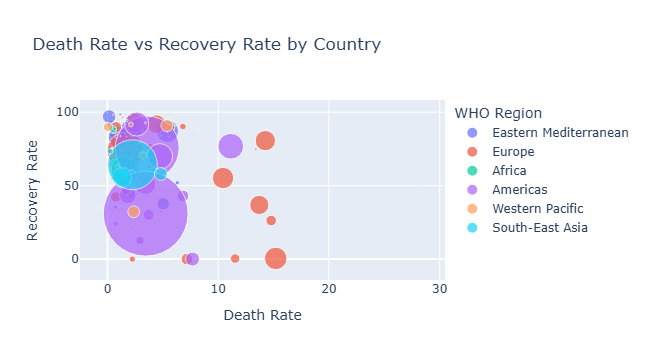

In [31]:
# Death Rate vs Recovery Rate
fig = px.scatter(df, 
                 x='Death Rate', 
                 y='Recovery Rate',
                 size='Confirmed',
                 color='WHO Region',
                 hover_name='Country/Region',
                 title='Death Rate vs Recovery Rate by Country',
                 size_max=60)
fig.show()

C:\Users\Dell\AppData\Local\Temp\ipykernel_13316\3150202234.py:2: DeprecationWarning:

The library used by the *country names* `locationmode` option is changing in an upcoming version. Country names in existing plots may not work in the new version. To ensure consistent behavior, consider setting `locationmode` to *ISO-3*.



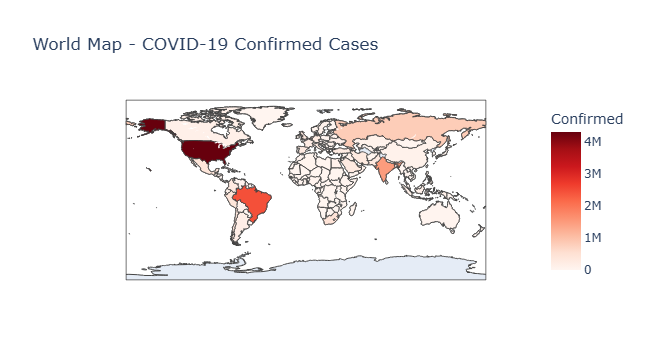

In [33]:
# World map of confirmed cases
fig = px.choropleth(df, 
                    locations='Country/Region',
                    locationmode='country names',
                    color='Confirmed',
                    title='World Map - COVID-19 Confirmed Cases',
                    color_continuous_scale='Reds',
                    hover_name='Country/Region')
fig.show()

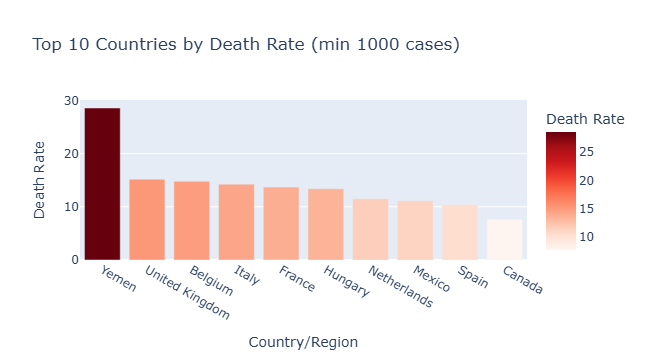

In [34]:
# Top 10 countries by death rate (min 1000 confirmed cases)
top_death_rate = df[df['Confirmed'] > 1000].sort_values(
                 'Death Rate', ascending=False).head(10)

fig = px.bar(top_death_rate,
             x='Country/Region',
             y='Death Rate',
             color='Death Rate',
             title='Top 10 Countries by Death Rate (min 1000 cases)',
             color_continuous_scale='Reds')
fig.show()

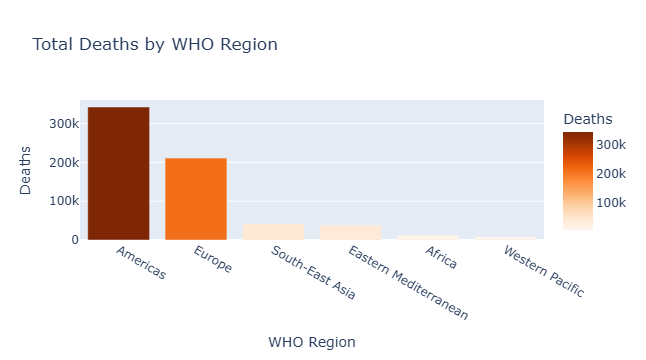

In [35]:
# WHO Region wise deaths
region_deaths = df.groupby('WHO Region')['Deaths'].sum().reset_index()
region_deaths = region_deaths.sort_values('Deaths', ascending=False)

fig = px.bar(region_deaths,
             x='WHO Region',
             y='Deaths',
             color='Deaths',
             title='Total Deaths by WHO Region',
             color_continuous_scale='Oranges')
fig.show()

C:\Users\Dell\AppData\Local\Temp\ipykernel_13316\2371126609.py:5: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




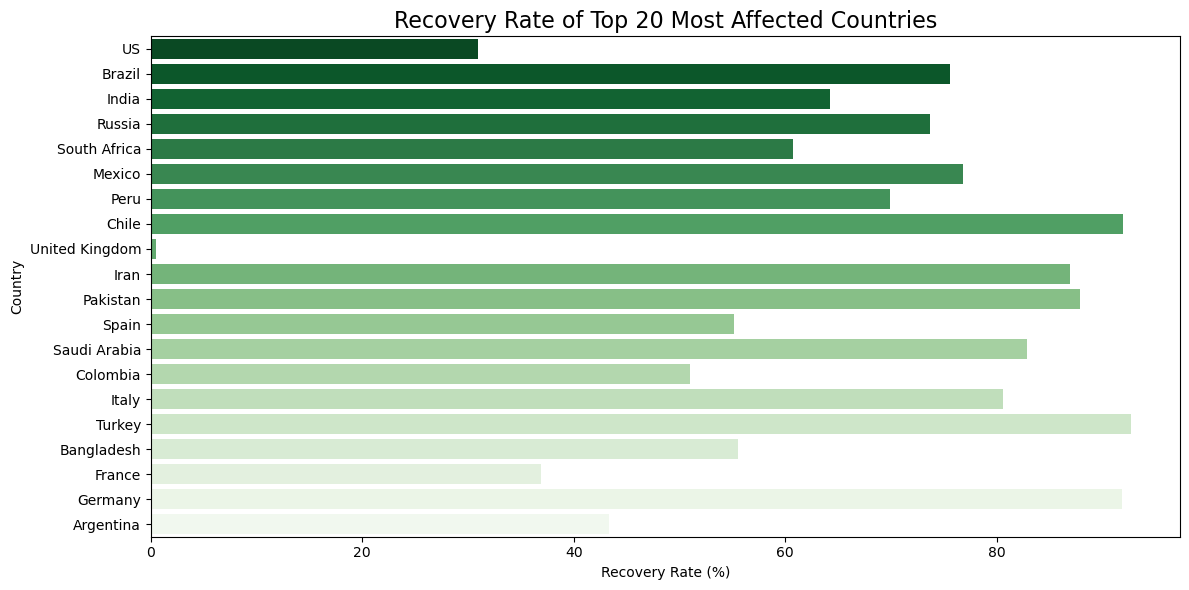

In [36]:
# Recovery rate of top 20 countries by confirmed cases
top20 = df.sort_values('Confirmed', ascending=False).head(20)

plt.figure(figsize=(12,6))
sns.barplot(x='Recovery Rate', y='Country/Region', 
            data=top20, palette='Greens_r')
plt.title('Recovery Rate of Top 20 Most Affected Countries', fontsize=16)
plt.xlabel('Recovery Rate (%)')
plt.ylabel('Country')
plt.tight_layout()
plt.show()

In [ ]:
print("=" * 60)
print("       COVID-19 GLOBAL ANALYSIS - KEY INSIGHTS")
print("=" * 60)

print("""
1. Total Countries Analyzed  : 187
2. Most Confirmed Cases       : USA
3. Most Deaths                : USA
4. Most Affected WHO Region   : Americas
5. Average Global Death Rate  : 3.02%
6. Geographically            : Americas, Europe & 
                                South Asia most affected
7. ⚠️  Countries with High Death 
       Rate had Low Recovery Rate (Negative Correlation)
8. 💚 Some smaller countries had 
       surprisingly high Recovery Rates
""")

print("=" * 60)
print("Analysis Complete! ✅")
print("=" * 60)